# VGG-19

In [1]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [2]:
DATA_DIR = "../data"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

assert os.path.exists(IMAGENETTE_PATH), f"Imagenette not found at {IMAGENETTE_PATH}"
print("Imagenette found, reusing existing download.")

Imagenette found, reusing existing download.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [64, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [ ]:
class VGG19(nn.Module):
    cfg = [64, 64, 'M',
           128, 128, 'M',
           256, 256, 256, 256, 'M',
           512, 512, 512, 512, 'M',
           512, 512, 512, 512, 'M']

    def __init__(self, num_classes=10):
        super().__init__()
        self.features = self._make_layers(self.cfg)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for v in cfg:
            if v == 'M':
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            else:
                layers.append(nn.Conv2d(in_channels, v, kernel_size=3, padding=1))
                layers.append(nn.ReLU(inplace=True))
                in_channels = v
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)

model = VGG19(num_classes=10).to(device)
print(model)

VGG19(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), pa

In [5]:
model.eval()
with torch.no_grad():
    sample_out = model(images.to(device))
print(f"Output shape: {sample_out.shape}")  # [64, 10]

Output shape: torch.Size([64, 10])


In [6]:
def count_conv_params(in_ch, out_ch, kernel_size=3):
    return (kernel_size * kernel_size * in_ch + 1) * out_ch

def count_fc_params(in_features, out_features):
    return (in_features + 1) * out_features

conv_channels = [
    (3, 64), (64, 64),
    (64, 128), (128, 128),
    (128, 256), (256, 256), (256, 256), (256, 256),
    (256, 512), (512, 512), (512, 512), (512, 512),
    (512, 512), (512, 512), (512, 512), (512, 512),
]

conv_total = sum(count_conv_params(i, o) for i, o in conv_channels)
fc6 = count_fc_params(512 * 7 * 7, 4096)
fc7 = count_fc_params(4096, 4096)
fc8 = count_fc_params(4096, 10)

manual_total = conv_total + fc6 + fc7 + fc8
torch_total = sum(p.numel() for p in model.parameters())

print(f"Conv layers total: {conv_total:,}")
print(f"FC6: {fc6:,}")
print(f"FC7: {fc7:,}")
print(f"FC8: {fc8:,}")
print(f"Manual total: {manual_total:,}")
print(f"torch total:  {torch_total:,}")
assert manual_total == torch_total, "Mismatch between manual and torch parameter count"

Conv layers total: 20,024,384
FC6: 102,764,544
FC7: 16,781,312
FC8: 40,970
Manual total: 139,611,210
torch total:  139,611,210


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [9]:
NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/10 | train_loss=2.3031 train_acc=0.0972 | val_loss=2.3033 val_acc=0.0910 | time=302.5s
Epoch 2/10 | train_loss=2.3025 train_acc=0.1032 | val_loss=2.3033 val_acc=0.0910 | time=300.1s
Epoch 3/10 | train_loss=2.3024 train_acc=0.1004 | val_loss=2.3036 val_acc=0.0910 | time=301.1s
Epoch 4/10 | train_loss=2.3024 train_acc=0.1032 | val_loss=2.3036 val_acc=0.0910 | time=303.5s
Epoch 5/10 | train_loss=2.3022 train_acc=0.1048 | val_loss=2.3036 val_acc=0.0910 | time=306.1s
Epoch 6/10 | train_loss=2.3023 train_acc=0.1048 | val_loss=2.3036 val_acc=0.0910 | time=300.0s
Epoch 7/10 | train_loss=2.3023 train_acc=0.1049 | val_loss=2.3035 val_acc=0.0910 | time=298.8s
Epoch 8/10 | train_loss=2.3023 train_acc=0.1028 | val_loss=2.3035 val_acc=0.0910 | time=298.9s
Epoch 9/10 | train_loss=2.3023 train_acc=0.1012 | val_loss=2.3035 val_acc=0.0910 | time=298.7s
Epoch 10/10 | train_loss=2.3023 train_acc=0.1048 | val_loss=2.3035 val_acc=0.0910 | time=298.8s


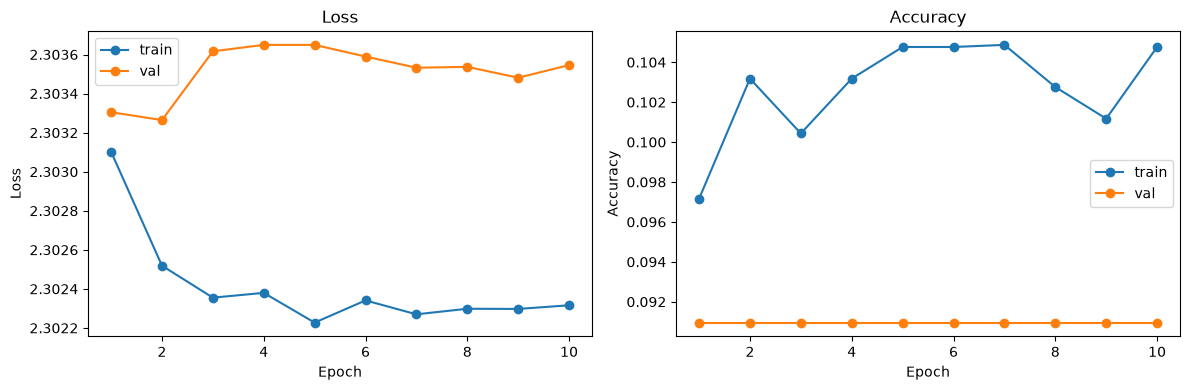

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

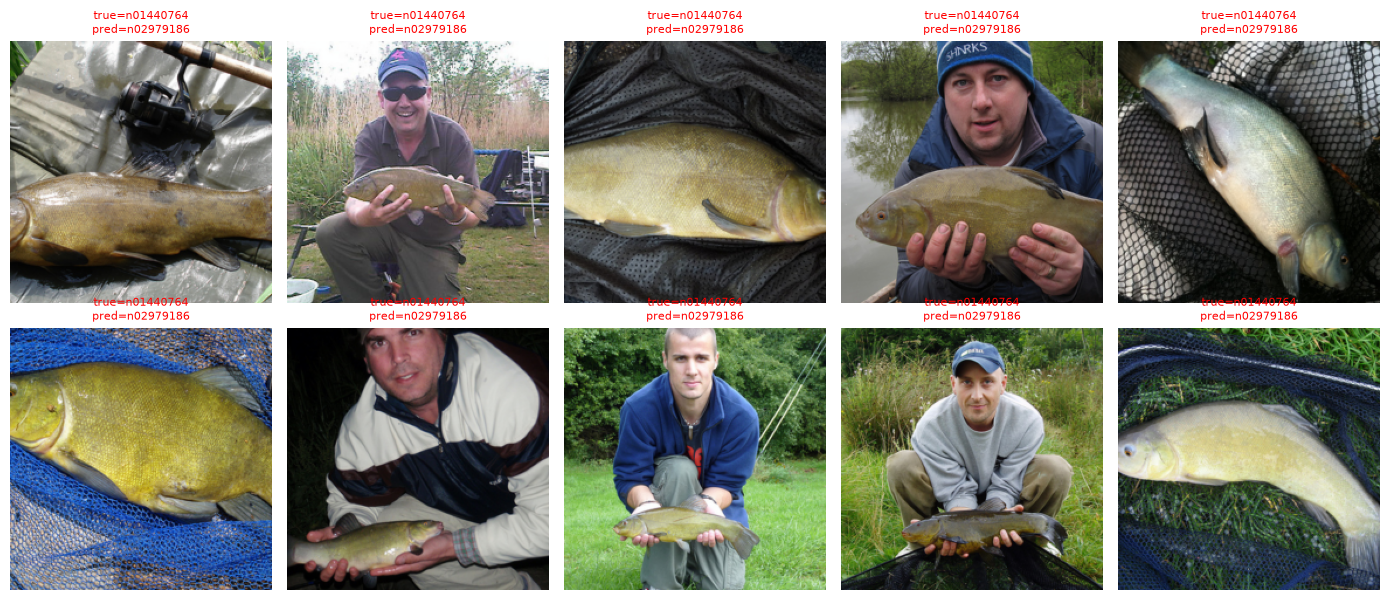

In [11]:
model.eval()
sample_images, sample_labels = next(iter(val_loader))
class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: see manual vs. torch count
above (matches exactly). VGG19 adds 3 extra conv layers over VGG16 (one
each in blocks 3, 4, 5), a modest increase in convolutional parameters -
the fully connected layers (FC6/FC7/FC8) still dominate the total, exactly
as in VGG16.

**Training dynamics — the network failed to learn.** Unlike VGG16, VGG19
did not escape the ln(10) ≈ 2.303 plateau at all over 10 epochs — train_loss
stayed flat at ~2.302-2.303 and val_acc was frozen at exactly 0.0910 on
every single epoch, meaning the model's predictions stopped changing
entirely after epoch 1. This is not simply "slower convergence" (as seen
with VGG16), it is a case of training effectively stalling.

The root cause is almost certainly **weight initialization** combined with
the lack of batch normalization (not yet invented when the original 2014
paper was published). VGG19 is three layers deeper than VGG16 (19 vs. 16
weight layers), all stacked with ReLU activations and no normalization
between them. With PyTorch's default Conv2d initialization - not tuned for
ReLU networks of this depth - gradients computed via backpropagation shrink
multiplicatively at each layer as they propagate back toward the input.
Three extra layers were apparently enough to push this vanishing gradient
problem from "slow" (VGG16's case) to "effectively zero": the earliest
layers likely receive gradients too small to produce any meaningful weight
update, so their random initial weights are never corrected, and the
network never escapes its initial random state.

This matches what the original VGG paper describes: the authors report that
very deep plain configurations were difficult to train from scratch and
worked around it by initializing deeper networks with weights from a
shallower, already-trained network - a workaround we did not apply here.
A more principled fix (e.g. Kaiming/He initialization, designed specifically
for ReLU networks) or adding batch normalization would likely resolve this,
but neither was applied in this run, so the result stands as a direct
illustration of why deep plain convolutional stacks are hard to train
without such measures - the exact motivation for architectures like ResNet.

**Why Adam instead of SGD with momentum.** The original paper used SGD with
momentum=0.9, weight decay, and a manually decayed learning rate. We used
Adam for simpler, more reliable convergence without manual tuning.